# Table of Contents
- [Introduction](#Introduction)
- [Dataset and Preprocessing](#Dataset-and-Preprocessing)
  - [Exploratory Data Analysis](#Exploratory-Data-Analysis)
  - [Encoding and Missing Value Imputation](#Encoding-and-Missing-Value-Imputation)
- [Classical Machine Learning Baselines](#Classical-Machine-Learning-Baselines)
  - [Top Feature Selection](#Top-Feature-Selection)
  - [FAMD](#FAMD)
- [Quantum Architecture](#QML-Architecture-and-Optimisation)
  - [Custom VQC](#Custom-VQC-with-Early-Stopping)
  - [Top Features VQC](#Top-Features-Baseline)
  - [FAMD VQC](#FAMD-Baseline)
  - [QNN Ensembles](#QNN-Ensembles)
    - [Test Search](#Test-Search)
    - [Full Search](#Full-Search)
- [Cloud Deployment](#Cloud-Deployment)
  - [Simulated Noise](#Simulated-Noise)
  - [Real Hardware Inference](#Real-Hardware-Inference)
- [Future Work](#Future-Work)

# Introduction

#### This notebook presents an end-to-end classification pipeline applied to a dataset of 17 mixed-type features and seven target classes. The data presents notable pre-processing challenges, including over 900 missing values, which are addressed using MissForest imputation. Two dimensionality reduction strategies,  direct feature importance selection and Factor Analysis of Mixed Data (FAMD),  are used to prepare four-qubit inputs for quantum models.

#### The quantum stage trains Variational Quantum Classifiers (VQCs) via a custom implementation supporting dynamic early stopping. A full search across 96 configurations, varying feature type, feature map, and ansatz is performed to identify the best-performing architectures. The top performers are then combined into an ensemble, to assess the potential for performance gains through model aggregation.

#### The final stage evaluates the best configurations under simulated hardware noise and deploys them on the real ibm_kingston quantum backend, providing insights into the practical performance of these models in real-world quantum environments. The notebook concludes with a discussion of future work, including potential improvements to the ensemble strategy and voting mechanisms, as well as suggestions for accelerating inference times on real hardware.

---
---

In [2]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt
%matplotlib inline
from IPython.display import clear_output
import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
import numpy as np
import random
import prince
from missforest import MissForest

# Dataset and Preprocessing

#### We begin by loading the dataset as is and performing an initial exploratory data analysis to understand the structure, distribution, and missing value patterns. The dataset contains 2,111 samples with 17 features, which include a mix of numerical and categorical variables. A significant portion of the data is missing, necessitating a robust imputation strategy to preserve the integrity of the dataset.

,class,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17
0,N,64.100473,3.0,1.000000,F,2.0,2.000000,no,P,1.620000,no,no,0.000000,no,yes,S,19.597920
1,N,56.188924,3.0,0.000000,F,3.0,3.000000,S,P,1.520000,yes,yes,3.000000,no,yes,S,21.281652
2,N,77.369576,3.0,1.000000,M,NaN,2.000000,F,P,1.800000,no,no,2.000000,no,yes,NaN,21.935498
3,1,88.560073,3.0,0.000000,M,3.0,2.000000,F,F,1.800000,no,no,2.000000,no,no,S,28.641032
4,2,90.597823,1.0,0.000000,M,2.0,2.000000,S,P,1.780000,no,no,0.000000,no,no,NaN,23.422159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,O3,130.248116,3.0,0.906247,F,3.0,NaN,S,P,1.710730,no,NaN,1.676269,yes,yes,S,22.091523
2107,O3,133.515621,3.0,0.599270,F,3.0,2.005130,S,P,1.748584,no,NaN,1.341390,yes,yes,S,24.427069
2108,O3,132.047615,3.0,0.646288,F,3.0,2.054193,S,P,1.752206,no,no,1.414209,yes,yes,S,23.466413
2109,O3,134.305696,3.0,0.586035,F,NaN,2.852339,S,P,1.739450,no,no,1.139107,yes,yes,S,22.119403


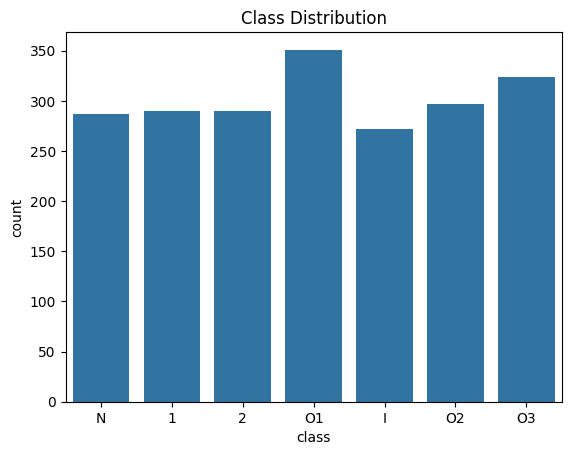

In [3]:
df = pd.read_csv("lab1-modified.csv")

# Keep only N classes
N = len(df['class'].unique())
# N = 3
classes = df['class'].unique()[:N]
df = df[df['class'].isin(classes)]

display(df)
# Class distribution
sns.countplot(x='class', data=df)
plt.title('Class Distribution')
plt.show()

## Exploratory Data Analysis

#### The classes are fairly balanced, with the largest and smallest classes comprising around 17% and 13% of the data, respectively.

## Encoding and Missing Value Imputation

#### Looking at the report we can see that some classes have up to 10% of their values missing, resulting in a total of over 900 missing values across the dataset. In order to address this, we will use the MissForest imputation algorithm, which uses Random Forests to predict and impute missing data across both categorical and numerical features. This specific implementation was also chosen for its ability to preserve the original data distribution and relationships between features, which is crucial for maintaining the integrity of the dataset for subsequent analysis.

In [4]:
labels = df['class'].astype("string")
label_names = sorted(labels.unique())
label_to_int = {label: idx for idx, label in enumerate(label_names)}
int_to_label = {idx: label for idx, label in enumerate(label_names)}
print(f"Label mapping: {label_to_int}")
labels = labels.map(label_to_int)

features = df.loc[:, 'X2':'X17']
features_num = ['X2', 'X3', 'X4', 'X6', 'X7', 'X10', 'X13', 'X17']
features_cat = ['X5', 'X8', 'X9', 'X11', 'X12', 'X14', 'X15', 'X16']

# convert categorical features to numeric values
for feature in features_cat:
    values = features[feature].unique()
    values = values[~pd.isnull(values)]
    mapping = {label: idx for idx, label in enumerate(values)}
    # print(f"Mapping for {feature}: {mapping}")
    features[feature] = features[feature].map(mapping)

features_train, features_test, y_train, y_test = train_test_split(features, labels, train_size=0.8, random_state=2, stratify=labels)

mf = MissForest(categorical=features_cat, verbose=1)

features_train = mf.fit_transform(features_train)
features_test = mf.transform(features_test)

features_train[features_cat] = features_train[features_cat].astype(int)
features_test[features_cat] = features_test[features_cat].astype(int)

display(pd.concat([y_train, features_train], axis=1).head())
display(pd.concat([y_test, features_test], axis=1).head())

Label mapping: {'1': 0, '2': 1, 'I': 2, 'N': 3, 'O1': 4, 'O2': 5, 'O3': 6}


100%|██████████| 5/5 [00:00<00:00, 77.00it/s]


,class,X2,X3,X4,X9,X8,X15,X14,X11,X5,X17,X13,X6,X12,X16,X7,X10
1911,6,133.907314,3.000000,0.625350,0,1,0,1,0,0,18.008365,1.536555,2.989235,0,0,2.923792,1.745602
1218,4,82.365608,1.000000,2.000000,0,1,0,1,0,0,22.339190,0.292093,1.810804,0,0,2.598632,1.608400
1660,5,121.134488,2.657720,0.000000,0,1,0,1,0,1,23.274485,0.870056,2.811050,0,0,2.104696,1.867410
363,3,79.125521,1.000000,1.000000,0,1,1,1,0,1,17.652645,2.000000,2.000000,0,0,2.000000,1.800000
1772,5,118.193323,2.993856,0.145284,0,1,0,1,0,1,24.566325,1.388962,2.191108,0,0,2.444917,1.788586


,class,X2,X3,X4,X9,X8,X15,X14,X11,X5,X17,X13,X6,X12,X16,X7,X10
789,0,65.517027,3.000000,0.480813,2,1,0,1,0,0,36.591143,2.892922,2.374640,0,0,2.000000,1.449559
1387,4,80.321076,1.317884,0.000000,2,0,0,1,0,0,42.412773,0.990642,2.766320,0,0,1.967408,1.582523
2010,6,103.939346,3.000000,0.541309,0,1,0,1,0,0,24.228630,0.000000,3.000000,0,0,1.292479,1.617390
8,3,64.881769,3.000000,1.000000,0,2,0,1,0,1,24.192968,1.000000,3.000000,0,0,2.000000,1.780000
1459,4,103.919796,3.000000,0.175694,0,1,0,1,0,1,23.199143,0.582160,2.253707,0,0,2.524432,1.785718


#### At this point, the dataset is split into training and testing sets using a stratified split. All subsequent data transformations, including sampling and encoding, are performed exclusively on the training set to prevent data leakage. The same transformations are then applied to the test set using the fitted parameters from the training data. This ensures that the evaluation of model performance is based entirely on unseen data, providing a realistic assessment of generalisation capabilities.

#### In order to train any of the models using the categorical features, we need to encode them into a numerical format. We use one-hot encoding, dropping the first category so binary features are represented by a single column, and to prevent multicollinearity in the dataset. This results in a total of 21 trainable features after encoding.

In [5]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

X_train_encoded = ohe.fit_transform(features_train[features_cat]).astype(int)
X_test_encoded = ohe.transform(features_test[features_cat]).astype(int)

X_train = pd.concat([features_train[features_num].reset_index(drop=True), pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(features_cat))], axis=1)
X_test = pd.concat([features_test[features_num].reset_index(drop=True), pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(features_cat))], axis=1)

display(X_train)
display(X_test)

,X2,X3,X4,X6,X7,X10,X13,X17,X5_1,X8_1,X8_2,X8_3,X9_1,X9_2,X11_1,X12_1,X14_1,X15_1,X16_1,X16_2,X16_3
0,133.907314,3.000000,0.625350,2.989235,2.923792,1.745602,1.536555,18.008365,0,1,0,0,0,0,0,0,1,0,0,0,0
1,82.365608,1.000000,2.000000,1.810804,2.598632,1.608400,0.292093,22.339190,0,1,0,0,0,0,0,0,1,0,0,0,0
2,121.134488,2.657720,0.000000,2.811050,2.104696,1.867410,0.870056,23.274485,1,1,0,0,0,0,0,0,1,0,0,0,0
3,79.125521,1.000000,1.000000,2.000000,2.000000,1.800000,2.000000,17.652645,1,1,0,0,0,0,0,0,1,1,0,0,0
4,118.193323,2.993856,0.145284,2.191108,2.444917,1.788586,1.388962,24.566325,1,1,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,66.859042,3.000000,1.000000,2.000000,1.000000,1.640000,0.000000,21.226280,1,0,0,0,0,0,0,0,0,0,0,0,0
1684,98.739188,2.993623,1.529423,2.000000,2.326635,1.732694,2.236586,21.494374,1,0,0,0,0,0,0,0,1,0,0,0,0
1685,95.973811,3.000000,1.229474,2.000000,2.697661,1.741353,2.614909,21.005434,1,0,0,0,0,0,0,0,1,0,0,0,0
1686,79.634810,3.171082,0.022245,1.993101,2.364498,1.745950,1.224743,24.969213,1,1,0,0,0,0,0,0,1,0,0,0,0


,X2,X3,X4,X6,X7,X10,X13,X17,X5_1,X8_1,X8_2,X8_3,X9_1,X9_2,X11_1,X12_1,X14_1,X15_1,X16_1,X16_2,X16_3
0,65.517027,3.000000,0.480813,2.374640,2.000000,1.449559,2.892922,36.591143,0,1,0,0,0,1,0,0,1,0,0,0,0
1,80.321076,1.317884,0.000000,2.766320,1.967408,1.582523,0.990642,42.412773,0,0,0,0,0,1,0,0,1,0,0,0,0
2,103.939346,3.000000,0.541309,3.000000,1.292479,1.617390,0.000000,24.228630,0,1,0,0,0,0,0,0,1,0,0,0,0
3,64.881769,3.000000,1.000000,3.000000,2.000000,1.780000,1.000000,24.192968,1,0,1,0,0,0,0,0,1,0,0,0,0
4,103.919796,3.000000,0.175694,2.253707,2.524432,1.785718,0.582160,23.199143,1,1,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,106.455606,3.000000,0.555468,3.009608,2.654702,1.629191,0.000000,27.070496,0,1,0,0,0,0,0,0,1,0,0,0,0
419,60.350897,3.000000,0.000000,2.000000,2.000000,1.650000,0.000000,22.742513,1,0,0,0,0,0,0,0,0,0,0,0,0
420,95.104136,3.000000,1.066603,2.000000,2.021270,1.701986,1.814869,22.698244,1,0,0,0,0,0,0,0,1,0,0,0,0
421,80.293832,3.000000,0.000000,2.000000,1.000000,1.529060,0.000000,40.067806,0,1,0,0,0,1,0,0,1,0,0,0,0


---

# Classical Machine Learning Baselines

#### A classical pipeline was trained on the fully preprocessed dataset to establish a robust performance benchmark. A basic Random Forest classifier achieves a testing accuracy of 93%, demonstrating the effectiveness of classical machine learning methods to handle the complexities of the dataset. This high level of performance provides a strong baseline against which the quantum approaches can be compared, highlighting the challenges and potential advantages of quantum machine learning in this context.

Training Accuracy: 1.0
Testing Accuracy: 0.9290780141843972
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.81      0.85        58
           1       0.91      0.91      0.91        58
           2       0.93      0.96      0.95        54
           3       0.78      0.88      0.83        58
           4       0.97      0.96      0.96        70
           5       1.00      0.97      0.98        60
           6       1.00      1.00      1.00        65

    accuracy                           0.93       423
   macro avg       0.93      0.93      0.93       423
weighted avg       0.93      0.93      0.93       423

Confusion Matrix:
 [[47  2  0  9  0  0  0]
 [ 2 53  0  2  1  0  0]
 [ 0  0 52  2  0  0  0]
 [ 2  1  4 51  0  0  0]
 [ 1  2  0  0 67  0  0]
 [ 0  0  0  1  1 58  0]
 [ 0  0  0  0  0  0 65]]


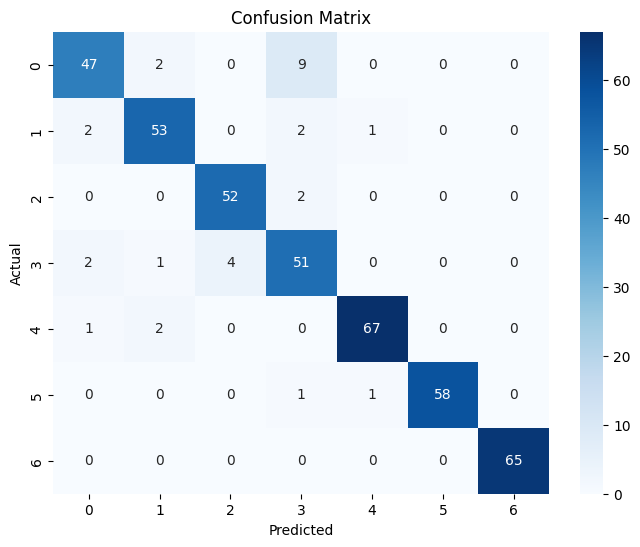

In [6]:
rf = RandomForestClassifier(n_estimators=200, random_state=2)
rf.fit(X_train, y_train)

print("Training Accuracy:", rf.score(X_train, y_train))
print("Testing Accuracy:", rf.score(X_test, y_test))

print("Classification Report:\n", classification_report(y_test, rf.predict(X_test)))

print("Confusion Matrix:\n", confusion_matrix(y_test, rf.predict(X_test)))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Top Feature Selection

#### To further explore the dataset and prepare the data for quantum machine learning models, we performed feature selection to identify the most informative features. Using a feature importance analysis from the Random Forest model, we can see the contribution of each feature to the model's performance.

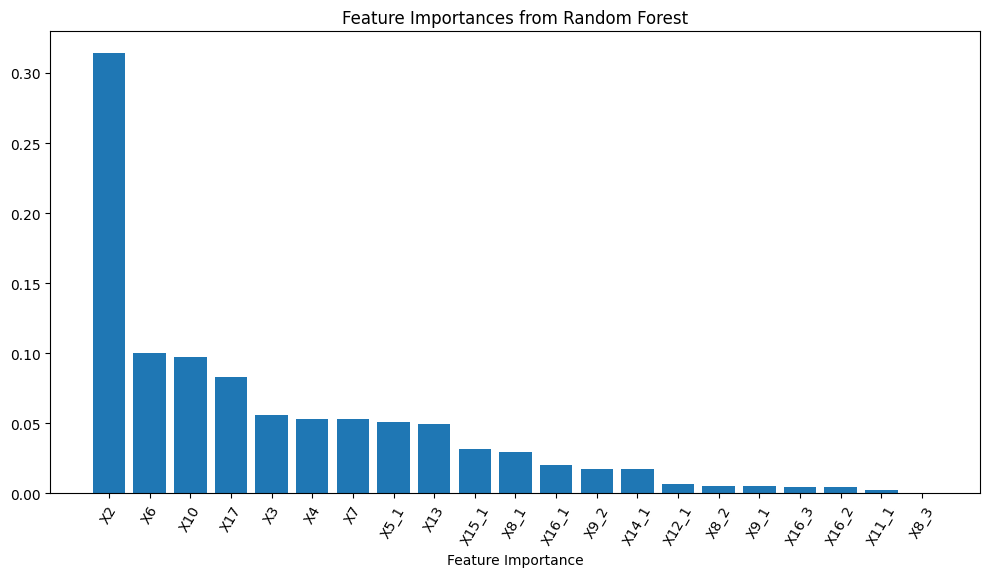

Top Features:
 ['X2', 'X6', 'X10', 'X17', 'X3', 'X4', 'X7', 'X5_1', 'X13', 'X15_1']


In [7]:
importances = rf.feature_importances_
importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(importances.index, importances)
plt.xlabel('Feature Importance')
plt.xticks(rotation=60)
plt.title('Feature Importances from Random Forest')
plt.show()

top_features = importances.head(10).index.tolist()
print("Top Features:\n", top_features)

#### Looking at the plot, we can see that 'X2' is the most important feature by a significant margin. Training a Random Forest model using only the top 4 features results in a testing accuracy of 92.5%, which is only a slight decrease from the 93% achieved using all features. This indicates that these top features capture most of the predictive power of the dataset, making them strong candidates for training quantum machine learning models where feature dimensionality can be a limiting factor. 

Training Accuracy: 1.0
Testing Accuracy: 0.9243498817966903
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.84        58
           1       0.89      0.95      0.92        58
           2       0.91      0.98      0.95        54
           3       0.89      0.83      0.86        58
           4       0.93      0.97      0.95        70
           5       0.98      0.93      0.96        60
           6       0.97      1.00      0.98        65

    accuracy                           0.92       423
   macro avg       0.92      0.92      0.92       423
weighted avg       0.92      0.92      0.92       423

Confusion Matrix:
 [[46  7  0  5  0  0  0]
 [ 1 55  0  0  2  0  0]
 [ 0  0 53  1  0  0  0]
 [ 5  0  5 48  0  0  0]
 [ 0  0  0  0 68  1  1]
 [ 0  0  0  0  3 56  1]
 [ 0  0  0  0  0  0 65]]


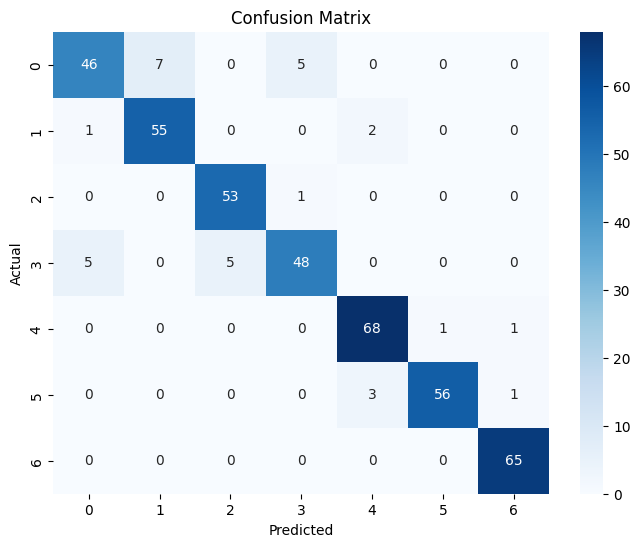

In [8]:
rf_top = RandomForestClassifier(n_estimators=200, random_state=2)
rf_top.fit(X_train[top_features[:4]], y_train)

print("Training Accuracy:", rf_top.score(X_train[top_features[:4]], y_train))
print("Testing Accuracy:", rf_top.score(X_test[top_features[:4]], y_test))

print("Classification Report:\n", classification_report(y_test, rf_top.predict(X_test[top_features[:4]])))

print("Confusion Matrix:\n", confusion_matrix(y_test, rf_top.predict(X_test[top_features[:4]])))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_top.predict(X_test[top_features[:4]])), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## FAMD

#### We also applied Factor Analysis of Mixed Data (FAMD) to the dataset, which is a dimensionality reduction technique that can handle both numerical and categorical data. FAMD allows us to project the data into a lower-dimensional space while preserving as much of the variance as possible.

In [9]:
famd = prince.FAMD(n_components=10, random_state=2, n_iter=5)
famd = famd.fit(features_train)
display(famd.plot(features_train, x_component=0, y_component=1))

Xf_train = famd.row_coordinates(features_train)
Xf_test = famd.row_coordinates(features_test)

display(Xf_train)

alt.LayerChart(...)

component,0,1,2,3,4,5,6,7,8,9
1911,-1.468208,0.276903,-1.991880,1.665992,0.229429,0.430481,-0.388358,-0.027717,0.191164,0.392011
1218,0.714526,-0.618230,-1.650259,-1.390567,0.296710,1.706740,1.324411,-0.891510,0.010644,0.161591
1660,-2.238483,0.281797,-0.672576,0.569318,0.563710,-0.540056,-0.125796,0.702596,-0.008144,-0.410528
363,0.405247,1.650545,-0.510070,-1.338986,1.324808,-0.165750,0.540286,0.183907,-0.076974,-0.326369
1772,-2.002027,0.604417,-0.415796,0.107035,0.729268,-0.443735,-0.272059,0.404912,-0.046416,-0.086728
...,...,...,...,...,...,...,...,...,...,...
57,1.451516,0.303109,0.447478,-1.254997,-1.246056,-0.086139,-0.521961,-0.363859,-0.504150,-1.602967
1394,-0.881631,1.897943,-0.426703,-1.222413,-0.707082,0.645786,-0.720979,-1.006865,0.317045,-0.150458
1448,-1.011257,2.155115,-0.333581,-0.944677,-0.354342,0.727815,-1.109787,-0.995599,0.431379,-0.052324
858,-1.090697,0.495533,-0.022242,-0.348468,0.713230,-0.693482,-0.282761,0.378846,-0.208985,0.082620


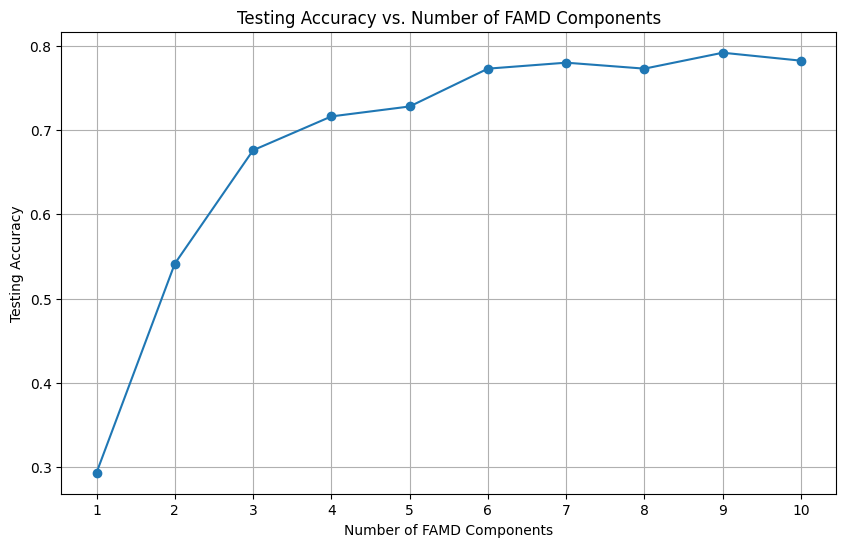

In [10]:
accs = []
for n in range(1, 11):
    rf_famd = RandomForestClassifier(n_estimators=200, random_state=2)
    rf_famd.fit(Xf_train[range(n)], y_train)
    accs.append(rf_famd.score(Xf_test[range(n)], y_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), accs, marker='o')
plt.xlabel('Number of FAMD Components')
plt.ylabel('Testing Accuracy')
plt.title('Testing Accuracy vs. Number of FAMD Components')
plt.xticks(range(1, 11))
plt.grid()
plt.show()

#### Training a Random Forest model on the N most variant FAMD components, we see that with just 4 components we can achieve a testing accuracy of 74%, which, while lower than the 92.5% achieved with the top 4 features, still demonstrates that FAMD can capture a significant amount of the underlying structure in the data.

Training Accuracy: 1.0
Testing Accuracy: 0.7163120567375887
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.34      0.43        58
           1       0.54      0.52      0.53        58
           2       0.77      0.94      0.85        54
           3       0.61      0.60      0.61        58
           4       0.64      0.69      0.66        70
           5       0.79      0.90      0.84        60
           6       1.00      1.00      1.00        65

    accuracy                           0.72       423
   macro avg       0.70      0.71      0.70       423
weighted avg       0.70      0.72      0.71       423

Confusion Matrix:
 [[20  8  6 11 12  1  0]
 [ 4 30  3  8  8  5  0]
 [ 2  0 51  0  0  1  0]
 [ 6  7  6 35  4  0  0]
 [ 3 10  0  2 48  7  0]
 [ 1  1  0  1  3 54  0]
 [ 0  0  0  0  0  0 65]]


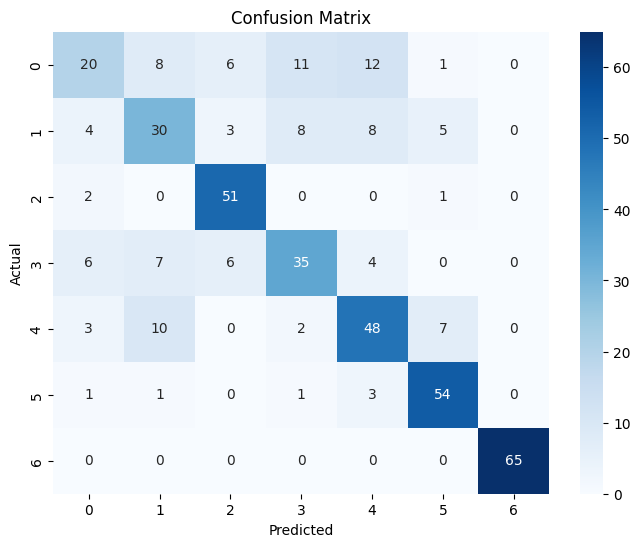

In [11]:
rf_famd = RandomForestClassifier(n_estimators=200, random_state=2)
rf_famd.fit(Xf_train[range(4)], y_train)

print("Training Accuracy:", rf_famd.score(Xf_train[range(4)], y_train))
print("Testing Accuracy:", rf_famd.score(Xf_test[range(4)], y_test))

print("Classification Report:\n", classification_report(y_test, rf_famd.predict(Xf_test[range(4)])))

print("Confusion Matrix:\n", confusion_matrix(y_test, rf_famd.predict(Xf_test[range(4)])))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_famd.predict(Xf_test[range(4)])), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
display(X_train[top_features[:10]])
# display(X_test[top_features[:10]])

# display(Xf_train)
# display(Xf_test)

Xf_train.columns = [f'C{i}' for i in range(Xf_train.shape[1])]
Xf_test.columns = [f'C{i}' for i in range(Xf_test.shape[1])]

display(Xf_train)
# display(Xf_test)

# combine features by alternating columns from X_train and Xf_train
combined_feats = []
for i in range(10):
    combined_feats.extend([top_features[i], Xf_train.columns[i]])
print("Combined Features:", combined_feats)

X_combined_train = pd.concat([X_train[top_features[:10]].reset_index(drop=True), Xf_train.reset_index(drop=True)], axis=1)[combined_feats]
X_combined_test = pd.concat([X_test[top_features[:10]].reset_index(drop=True), Xf_test.reset_index(drop=True)], axis=1)[combined_feats]

display(X_combined_train)
# display(X_combined_test)

combined_train = pd.concat([y_train.reset_index(drop=True), X_combined_train], axis=1)
combined_test = pd.concat([y_test.reset_index(drop=True), X_combined_test], axis=1)

display(combined_train)
display(combined_test)

# save combined features to csv
combined_train.to_csv("lab1-train-processed.csv", index=False)
combined_test.to_csv("lab1-test-processed.csv", index=False)

,X2,X6,X10,X17,X3,X4,X7,X5_1,X13,X15_1
0,133.907314,2.989235,1.745602,18.008365,3.000000,0.625350,2.923792,0,1.536555,0
1,82.365608,1.810804,1.608400,22.339190,1.000000,2.000000,2.598632,0,0.292093,0
2,121.134488,2.811050,1.867410,23.274485,2.657720,0.000000,2.104696,1,0.870056,0
3,79.125521,2.000000,1.800000,17.652645,1.000000,1.000000,2.000000,1,2.000000,1
4,118.193323,2.191108,1.788586,24.566325,2.993856,0.145284,2.444917,1,1.388962,0
...,...,...,...,...,...,...,...,...,...,...
1683,66.859042,2.000000,1.640000,21.226280,3.000000,1.000000,1.000000,1,0.000000,0
1684,98.739188,2.000000,1.732694,21.494374,2.993623,1.529423,2.326635,1,2.236586,0
1685,95.973811,2.000000,1.741353,21.005434,3.000000,1.229474,2.697661,1,2.614909,0
1686,79.634810,1.993101,1.745950,24.969213,3.171082,0.022245,2.364498,1,1.224743,0


,C0,C1,C2,C3,C4,C5,C6,C7,C8,C9
1911,-1.468208,0.276903,-1.991880,1.665992,0.229429,0.430481,-0.388358,-0.027717,0.191164,0.392011
1218,0.714526,-0.618230,-1.650259,-1.390567,0.296710,1.706740,1.324411,-0.891510,0.010644,0.161591
1660,-2.238483,0.281797,-0.672576,0.569318,0.563710,-0.540056,-0.125796,0.702596,-0.008144,-0.410528
363,0.405247,1.650545,-0.510070,-1.338986,1.324808,-0.165750,0.540286,0.183907,-0.076974,-0.326369
1772,-2.002027,0.604417,-0.415796,0.107035,0.729268,-0.443735,-0.272059,0.404912,-0.046416,-0.086728
...,...,...,...,...,...,...,...,...,...,...
57,1.451516,0.303109,0.447478,-1.254997,-1.246056,-0.086139,-0.521961,-0.363859,-0.504150,-1.602967
1394,-0.881631,1.897943,-0.426703,-1.222413,-0.707082,0.645786,-0.720979,-1.006865,0.317045,-0.150458
1448,-1.011257,2.155115,-0.333581,-0.944677,-0.354342,0.727815,-1.109787,-0.995599,0.431379,-0.052324
858,-1.090697,0.495533,-0.022242,-0.348468,0.713230,-0.693482,-0.282761,0.378846,-0.208985,0.082620


Combined Features: ['X2', 'C0', 'X6', 'C1', 'X10', 'C2', 'X17', 'C3', 'X3', 'C4', 'X4', 'C5', 'X7', 'C6', 'X5_1', 'C7', 'X13', 'C8', 'X15_1', 'C9']


,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,133.907314,-1.468208,2.989235,0.276903,1.745602,-1.991880,18.008365,1.665992,3.000000,0.229429,0.625350,0.430481,2.923792,-0.388358,0,-0.027717,1.536555,0.191164,0,0.392011
1,82.365608,0.714526,1.810804,-0.618230,1.608400,-1.650259,22.339190,-1.390567,1.000000,0.296710,2.000000,1.706740,2.598632,1.324411,0,-0.891510,0.292093,0.010644,0,0.161591
2,121.134488,-2.238483,2.811050,0.281797,1.867410,-0.672576,23.274485,0.569318,2.657720,0.563710,0.000000,-0.540056,2.104696,-0.125796,1,0.702596,0.870056,-0.008144,0,-0.410528
3,79.125521,0.405247,2.000000,1.650545,1.800000,-0.510070,17.652645,-1.338986,1.000000,1.324808,1.000000,-0.165750,2.000000,0.540286,1,0.183907,2.000000,-0.076974,1,-0.326369
4,118.193323,-2.002027,2.191108,0.604417,1.788586,-0.415796,24.566325,0.107035,2.993856,0.729268,0.145284,-0.443735,2.444917,-0.272059,1,0.404912,1.388962,-0.046416,0,-0.086728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,66.859042,1.451516,2.000000,0.303109,1.640000,0.447478,21.226280,-1.254997,3.000000,-1.246056,1.000000,-0.086139,1.000000,-0.521961,1,-0.363859,0.000000,-0.504150,0,-1.602967
1684,98.739188,-0.881631,2.000000,1.897943,1.732694,-0.426703,21.494374,-1.222413,2.993623,-0.707082,1.529423,0.645786,2.326635,-0.720979,1,-1.006865,2.236586,0.317045,0,-0.150458
1685,95.973811,-1.011257,2.000000,2.155115,1.741353,-0.333581,21.005434,-0.944677,3.000000,-0.354342,1.229474,0.727815,2.697661,-1.109787,1,-0.995599,2.614909,0.431379,0,-0.052324
1686,79.634810,-1.090697,1.993101,0.495533,1.745950,-0.022242,24.969213,-0.348468,3.171082,0.713230,0.022245,-0.693482,2.364498,-0.282761,1,0.378846,1.224743,-0.208985,0,0.082620


,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,6,133.907314,-1.468208,2.989235,0.276903,1.745602,-1.991880,18.008365,1.665992,3.000000,0.229429,0.625350,0.430481,2.923792,-0.388358,0,-0.027717,1.536555,0.191164,0,0.392011
1,4,82.365608,0.714526,1.810804,-0.618230,1.608400,-1.650259,22.339190,-1.390567,1.000000,0.296710,2.000000,1.706740,2.598632,1.324411,0,-0.891510,0.292093,0.010644,0,0.161591
2,5,121.134488,-2.238483,2.811050,0.281797,1.867410,-0.672576,23.274485,0.569318,2.657720,0.563710,0.000000,-0.540056,2.104696,-0.125796,1,0.702596,0.870056,-0.008144,0,-0.410528
3,3,79.125521,0.405247,2.000000,1.650545,1.800000,-0.510070,17.652645,-1.338986,1.000000,1.324808,1.000000,-0.165750,2.000000,0.540286,1,0.183907,2.000000,-0.076974,1,-0.326369
4,5,118.193323,-2.002027,2.191108,0.604417,1.788586,-0.415796,24.566325,0.107035,2.993856,0.729268,0.145284,-0.443735,2.444917,-0.272059,1,0.404912,1.388962,-0.046416,0,-0.086728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,3,66.859042,1.451516,2.000000,0.303109,1.640000,0.447478,21.226280,-1.254997,3.000000,-1.246056,1.000000,-0.086139,1.000000,-0.521961,1,-0.363859,0.000000,-0.504150,0,-1.602967
1684,4,98.739188,-0.881631,2.000000,1.897943,1.732694,-0.426703,21.494374,-1.222413,2.993623,-0.707082,1.529423,0.645786,2.326635,-0.720979,1,-1.006865,2.236586,0.317045,0,-0.150458
1685,4,95.973811,-1.011257,2.000000,2.155115,1.741353,-0.333581,21.005434,-0.944677,3.000000,-0.354342,1.229474,0.727815,2.697661,-1.109787,1,-0.995599,2.614909,0.431379,0,-0.052324
1686,0,79.634810,-1.090697,1.993101,0.495533,1.745950,-0.022242,24.969213,-0.348468,3.171082,0.713230,0.022245,-0.693482,2.364498,-0.282761,1,0.378846,1.224743,-0.208985,0,0.082620


,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,0,65.517027,0.484487,2.374640,-1.847356,1.449559,1.590055,36.591143,0.396030,3.000000,-0.189425,0.480813,0.340385,2.000000,-1.107690,0,-0.227402,2.892922,0.179947,0,1.047396
1,4,80.321076,0.109128,2.766320,-3.276887,1.582523,2.075080,42.412773,-0.221815,1.317884,-0.121852,0.000000,1.570310,1.967408,-1.178837,0,-0.372068,0.990642,0.527927,0,-0.123479
2,6,103.939346,0.073094,3.000000,-1.897598,1.617390,-1.372753,24.228630,0.688670,3.000000,-0.626943,0.541309,-0.320001,1.292479,0.558842,0,0.421557,0.000000,-0.395995,0,-0.056059
3,3,64.881769,-0.796613,3.000000,1.193776,1.780000,1.134938,24.192968,0.908599,3.000000,-0.281191,1.000000,0.873024,2.000000,2.358295,1,-2.152621,1.000000,0.820595,0,2.345712
4,4,103.919796,-1.670365,2.253707,0.339208,1.785718,-0.616425,23.199143,-0.033524,3.000000,0.776164,0.175694,-0.464756,2.524432,0.078508,1,0.435049,0.582160,-0.180257,0,0.012671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,6,106.455606,-0.521648,3.009608,-1.567272,1.629191,-1.414409,27.070496,1.220609,3.000000,0.150220,0.555468,0.401723,2.654702,0.222386,0,0.132335,0.000000,-0.099324,0,0.446954
419,3,60.350897,0.979537,2.000000,0.074900,1.650000,0.661700,22.742513,-0.687676,3.000000,-0.106647,0.000000,0.040351,2.000000,-1.063919,1,-0.124470,0.000000,-0.350357,0,-1.211942
420,4,95.104136,-0.641643,2.000000,1.167839,1.701986,-0.225637,22.698244,-1.236276,3.000000,-0.591072,1.066603,0.349936,2.021270,-0.624453,1,-0.686549,1.814869,0.152797,0,-0.284635
421,4,80.293832,0.202996,2.000000,-3.692421,1.529060,1.813763,40.067806,-0.553698,3.000000,-0.338952,0.000000,-0.623399,1.000000,0.189557,0,0.530507,0.000000,-0.555358,0,0.418316


#### As a final benchmark, we also trained a K-Nearest Neighbour (KNN) model on the top 4 FAMD components, which achieved a testing accuracy of 76%.

In [13]:
knn_famd = KNeighborsClassifier(n_neighbors=5)
knn_famd.fit(Xf_train[range(4)], y_train)

print("Training Accuracy:", knn_famd.score(Xf_train[range(4)], y_train))
print("Testing Accuracy:", knn_famd.score(Xf_test[range(4)], y_test))

print("Classification Report:\n", classification_report(y_test, knn_famd.predict(Xf_test[range(4)])))

print("Confusion Matrix:\n", confusion_matrix(y_test, knn_famd.predict(Xf_test[range(4)])))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, knn_famd.predict(Xf_test[range(4)])), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

KeyError: "None of [Index([0, 1, 2, 3], dtype='int64')] are in the [columns]"

---
---

# QML Architecture and Optimisation

In [ ]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import AngleEmbedding, IQPEmbedding, StronglyEntanglingLayers, BasicEntanglerLayers
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

import time
import copy
from typing import Literal

plt.rcParams["figure.figsize"] = (12, 6)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cpu"
print(f"Using device: {DEVICE}\n")
qml.about()

Using device: cpu

Name: pennylane
Version: 0.45.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /home/edwar/.pyenv/versions/3.14.5/lib/python3.14/site-packages
Platform info:           Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Python version:          3.14.5
Numpy version:           2.4.6
Scipy version:           1.17.1
JAX version:             None
Catalyst version:        None
Installed devices:
- lightning.gpu (pennylane_lightning_gpu-0.45.0)
- default.clifford (pennylane-0.45.0)
- default.gaussian (pennylane-0.45.0)
- default.mixed (pennylane-0.45.0)
- default.qubit (pennylane-0.45.0)
- default.qutrit (pennylane-0.45.0)
- default.qutrit.mixed (pennylane-0.45.0)
- default.tensor (pennylane-0.45.0)
- null.qubit (pennylane-0.45.0)
- reference.qubit (pennylane-0.45.0)
- lightning.qubit (pe

## Custom VQC with Early Stopping

#### To more easily facilitate the training of a custom Variational Quantum Classifier (VQC) on the dataset, the VQC class was extended to include support for early stopping, by monitoring the the variation of the objective function value across iterations. If the change in the objective function value falls below a dynamically calculated threshold over a specified number of iterations, the training process is halted.

## Optimiser Selection

#### Both SPSA and COBYLA were evaluated as candidate optimisers for the VQC across all experimental stages, to determine which produced more generalisable parameter updates under the constraints of the circuit architecture. At the baseline level, SPSA achieved testing accuracies of 22% and 31% on the top-feature and FAMD-derived inputs respectively, compared to 20% and 26% for COBYLA on the same configurations.

| Optimiser | Input | Train Acc | Test Acc |
|---|---|---|---|
| COBYLA | Top features | 18% | 20% |
| SPSA | Top features | 23% | 22% |
| COBYLA | FAMD | 29% | 26% |
| SPSA | FAMD | 32% | 31% |

#### SPSA achieved higher overall accuracies across both input configurations, with a smaller gap between training and testing performance, suggesting better generalisation capabilities. SPSA also demonstrated more stable convergence patterns, with fewer instances of erratic parameter updates compared to COBYLA, which exhibited more variability in the objective function values across iterations. Based on these observations, SPSA was selected as the optimiser for all subsequent experiments.

#### To setup the VQC and train an initial quantum baseline, we first define the quantum circuit architecture, which consists of 4 qubits corresponding to the top 4 features/components selected from the classical analysis.

#### The circuit consists of a ZZ Feature Map with 2 repetitions, which encodes the input data into the quantum state, followed by a Real Amplitudes ansatz with 2 repetitions.

In [ ]:
n_qubits = 4

if DEVICE == "cuda":
    dev = qml.device("lightning.gpu", wires=n_qubits)
else:
    dev = qml.device("default.qubit", wires=n_qubits)
    
scaler = MinMaxScaler(feature_range=(0, np.pi))

def init_weights(shape, weights_mode: Literal["Random", "Zeros"] = "Random"):
    if weights_mode == "Random":
        return np.random.uniform(0, 2 * np.pi, size=shape)
    elif weights_mode == "Zeros":
        return np.zeros(shape)

(<Figure size 500x500 with 1 Axes>, <Axes: >)
<default.qubit device (wires=4) at 0x773139a34440>
best


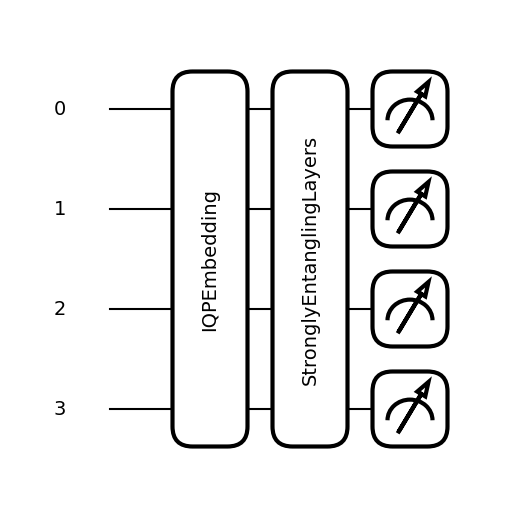

In [ ]:
@qml.qnode(dev, interface='torch', diff_method='best')
def circuit(inputs, weights):
    IQPEmbedding(inputs, wires=range(n_qubits), n_repeats=2)
    StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return qml.probs(wires=range(n_qubits))

weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=n_qubits)
weights = init_weights(weights_shape)

print(qml.draw_mpl(circuit)(np.zeros(n_qubits), weights))
print(circuit.device)
print(circuit.diff_method)

In [ ]:
qlayer = qml.qnn.TorchLayer(circuit, weight_shapes={"weights": weights_shape})

In [ ]:
def train(
    model,
    train_loader,
    test_loader,
    epochs=100,
    lr=0.01,
    optimizer_cls=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss(),
    patience=15,
    warmup=15,
    min_delta=1e-4,
    plot=True,
    restore_best=True,
    verbose=True,
):
    model = model.to(DEVICE)

    optimizer = optimizer_cls(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):

        # Training
        epoch_loss = 0.0
        model.train()
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            if verbose:
                print(f"[Epoch {epoch + 1}/{epochs}] Batch {batch_idx + 1}/{len(train_loader)}", end="\r")

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        val_loss = 0.0
        correct = 0
        total = 0
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                val_loss += loss.item()

                preds = logits.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        avg_val_loss = val_loss / len(test_loader)
        val_acc = correct / total

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)
        
        # Plot
        if plot:
            clear_output(wait=True)
            plt.figure(figsize=(10, 6))
            plt.plot(train_losses, label="Train Loss")
            plt.plot(val_losses, label="Validation Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title("Training and Validation Loss")
            plt.legend()
            plt.grid(True)
            plt.xlim(0, max(1, len(train_losses)))
            plt.show()

        if verbose:
            print(f"[Epoch {epoch + 1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.3f}")
        
        # Early stopping
        if epoch >= warmup:
            if avg_val_loss < best_val_loss - min_delta:
                best_val_loss = avg_val_loss
                patience_counter = 0

                if restore_best:
                    best_state = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1

            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch + 1}")
                break
        else:
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss

                if restore_best:
                    best_state = copy.deepcopy(model.state_dict())

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "best_val_loss": best_val_loss,
        "final_val_accuracy": val_accuracies[-1],
    }

    return history

def predict(model, loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(DEVICE)
            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
    return all_preds

def score(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)
            preds = logits.argmax(dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

In [ ]:
class VQC(nn.Module):
    def __init__(self, n_qubits, n_classes, qlayer):
        super().__init__()
        self.qlayer = qlayer
        self.classifier = nn.Linear(2 ** n_qubits, n_classes)
  
    def forward(self, x):
        q_out = self.qlayer(x)
        return self.classifier(q_out)

## Top Features Baseline

#### The first quantum model was trained using the top 4 features identified from the classical feature importance analysis. This model achieved a final testing accuracy of 20%, slightly above the random baseline of 14.3% for a 7-class classification problem, indicating that the VQC is able to capture some of the underlying structure in the data, but there is significant room for improvement.

In [ ]:
X1_train = pd.DataFrame(scaler.fit_transform(X_train[top_features[:n_qubits]]), columns=top_features[:n_qubits])
X1_test = pd.DataFrame(scaler.transform(X_test[top_features[:n_qubits]]), columns=top_features[:n_qubits])

X_tr = torch.tensor(X1_train.values, dtype=torch.float32).to(DEVICE)
y_tr = torch.tensor(y_train.values, dtype=torch.long).to(DEVICE)
X_te = torch.tensor(X1_test.values, dtype=torch.float32).to(DEVICE)
y_te = torch.tensor(y_test.values, dtype=torch.long).to(DEVICE)

trainloader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
testloader = DataLoader(TensorDataset(X_te, y_te), batch_size=32, shuffle=False)

display(X1_train)

,X2,X6,X10,X17
0,2.238269,3.109305,1.663855,0.305616
1,1.040603,1.267341,0.798880,0.597865
2,1.941469,2.830790,2.431781,0.660980
3,0.965313,1.563066,2.006802,0.281612
4,1.873126,1.861780,1.934844,0.748154
...,...,...,...,...
1683,0.680279,1.563066,0.998099,0.522765
1684,1.421073,1.563066,1.582478,0.540856
1685,1.356814,1.563066,1.637068,0.507862
1686,0.977147,1.552282,1.666049,0.775342


In [1]:
model = VQC(n_qubits=4, n_classes=7, qlayer=qlayer).to(DEVICE)
hist = train(model=model, train_loader=trainloader, test_loader=testloader)

NameError: name 'VQC' is not defined

In [ ]:
train_score = score(model, trainloader)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_te, predict(model, testloader), zero_division=0))

Training Accuracy: 0.67
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.45      0.47        58
           1       0.37      0.31      0.34        58
           2       0.84      0.91      0.88        54
           3       0.56      0.50      0.53        58
           4       0.65      0.77      0.71        70
           5       0.68      0.65      0.67        60
           6       0.83      0.92      0.88        65

    accuracy                           0.65       423
   macro avg       0.63      0.64      0.64       423
weighted avg       0.64      0.65      0.64       423



## FAMD Baseline

#### The second quantum model was trained using the top 4 FAMD components, which achieved a testing accuracy of 26%, demonstrating that the dimensionality reduction provided by FAMD is better suited for the VQC architecture, allowing it to capture more of the underlying structure in the data compared to using the top features directly.

In [ ]:
X2_train = pd.DataFrame(scaler.fit_transform(Xf_train[range(n_qubits)]), columns=Xf_train.columns[:n_qubits])
X2_test = pd.DataFrame(scaler.transform(Xf_test[range(n_qubits)]), columns=Xf_test.columns[:n_qubits])

X_tr = torch.tensor(X2_train.values, dtype=torch.float32).to(DEVICE)
y_tr = torch.tensor(y_train.values, dtype=torch.long).to(DEVICE)
X_te = torch.tensor(X2_test.values, dtype=torch.float32).to(DEVICE)
y_te = torch.tensor(y_test.values, dtype=torch.long).to(DEVICE)

trainloader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
testloader = DataLoader(TensorDataset(X_te, y_te), batch_size=32, shuffle=False)

display(X2_train)

component,0,1,2,3
0,0.567458,1.295030,0.038224,2.027824
1,1.407017,1.007058,0.156348,1.008427
2,0.271183,1.296605,0.494406,1.662071
3,1.288057,1.736943,0.550597,1.025629
4,0.362132,1.400394,0.583195,1.507894
...,...,...,...,...
1683,1.690489,1.303461,0.881693,1.053641
1684,0.793077,1.816533,0.579423,1.064508
1685,0.743218,1.899268,0.611623,1.157136
1686,0.712663,1.365365,0.719276,1.355978


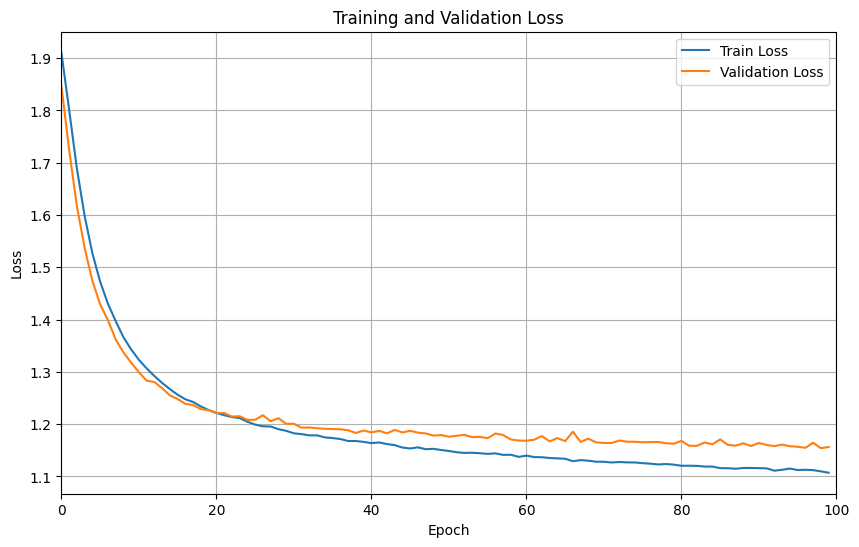

[Epoch 100/100] Train Loss: 1.1072 | Val Loss: 1.1565 | Val Acc: 0.539


In [ ]:
model = VQC(n_qubits=4, n_classes=7, qlayer=qlayer).to(DEVICE)
hist = train(model=model, train_loader=trainloader, test_loader=testloader)

In [ ]:
train_score = score(model, trainloader)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_te, predict(model, testloader), zero_division=0))

Training Accuracy: 0.56
Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.21      0.26        58
           1       0.22      0.14      0.17        58
           2       0.47      0.63      0.54        54
           3       0.41      0.34      0.37        58
           4       0.45      0.59      0.51        70
           5       0.62      0.77      0.69        60
           6       1.00      1.00      1.00        65

    accuracy                           0.53       423
   macro avg       0.50      0.52      0.50       423
weighted avg       0.51      0.53      0.51       423



---

# QNN Ensembles

## Test Search

#### Initial evaluations of singular four-qubit Variational Quantum Classifiers yielded accuracies slightly above random guessing. Looking at the classification reports, however, we can see that the 2 models have higher F1-scores for different classes, indicating that they are capturing different aspects of the data distribution. This observation motivated the construction of an ensemble architecture to leverage the complementary strengths of the individual models and improve overall performance.

#### A custom ensemble class was implemented to allow for the training of multiple VQC models on different subsets of the data, with the final prediction being made by aggregating the outputs of the individual models. For the voting mechanism, different strategies were explored, including majority voting and weighted voting based on the probability distributions output by the individual models.

In [ ]:
from scipy.linalg import hadamard
import numpy as np

def build_ecoc_matrix(n_classes, ensemble_size):
    n = 2 ** int(np.ceil(np.log2(ensemble_size)) + 1)

    H = hadamard(n)[:n_classes]

    code = ((H + 1) // 2).astype(int)

    mask = (code.sum(0) > 0) & (code.sum(0) < n_classes)
    code = code[:, mask]

    return code[:, :ensemble_size]

print(build_ecoc_matrix(10, 14))

[[1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 0 1 1 0 0 1 1 0 0 1 1 0]
 [0 0 1 1 0 0 1 1 0 0 1 1 0 0]
 [1 1 1 0 0 0 0 1 1 1 1 0 0 0]
 [0 1 0 0 1 0 1 1 0 1 0 0 1 0]
 [1 0 0 0 0 1 1 1 1 0 0 0 0 1]
 [0 0 1 0 1 1 0 1 0 0 1 0 1 1]
 [1 1 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 1 0 1 0 1 0 0 1 0 1 0 1 0]]
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [1 0 0 1 1 0 0 1 1 0 0 1 1 0 0]
 [0 0 1 1 0 0 1 1 0 0 1 1 0 0 1]
 [1 1 1 0 0 0 0 1 1 1 1 0 0 0 0]
 [0 1 0 0 1 0 1 1 0 1 0 0 1 0 1]
 [1 0 0 0 0 1 1 1 1 0 0 0 0 1 1]
 [0 0 1 0 1 1 0 1 0 0 1 0 1 1 0]
 [1 1 1 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 1 0 0 1 0 1 0 1 0 1]]


In [15]:
def build_ecoc_matrix(c, n):
    matrix = np.zeros((n, c), dtype=int)
    for i in range(c):
        for j in range(c):
            matrix[i, j] = random.randint(0, 1)

    max = ((2**c) / 2) - 1

    while True:
        # find the duplicate rows, complementary rows, and degenerate rows (rows that are all 0s or all 1s) 
        # then regenerate only those rows
        row_tuples = [tuple(row) for row in matrix]
        row_counts = {}
        for idx, row in enumerate(row_tuples):
            if row in row_counts:
                row_counts[row].append(idx)
            else:
                row_counts[row] = [idx]

        has_duplicates = False
        has_complements = False
        has_degenerate = False
        for row, indices in row_counts.items():
            # check for complements and duplicates only if n is less than the maximum number of unique rows
            if n <= max:
                if len(indices) > 1:
                    has_duplicates = True
                    for idx in indices:
                        for j in range(c):
                            matrix[idx, j] = random.randint(0, 1)

                complement = tuple(1 - np.array(row))
                if complement in row_counts:
                    has_complements = True
                    for idx in row_counts[complement]:
                        for j in range(c):
                            matrix[idx, j] = random.randint(0, 1)

            if all(x == 0 for x in row) or all(x == 1 for x in row):
                has_degenerate = True
                for idx in row_counts[row]:
                    for j in range(c):
                        matrix[idx, j] = random.randint(0, 1)

        if not has_duplicates and not has_complements and not has_degenerate:
            break

    # as a final cleanup check if a row has more 1s than 0s, if so flip the bits
    for i in range(n):
        if sum(matrix[i]) > c / 2:
            matrix[i] = 1 - matrix[i]

    return matrix

matrix = build_ecoc_matrix(7, 14)
print(matrix)

[[1 0 0 1 0 0 1]
 [1 0 1 0 1 0 0]
 [0 0 0 0 1 0 1]
 [0 0 0 0 0 0 1]
 [1 1 0 0 1 0 0]
 [0 1 0 0 0 1 1]
 [0 0 1 1 0 0 0]
 [0 1 1 0 0 0 0]
 [0 1 0 0 0 1 0]
 [0 1 0 1 0 0 1]
 [0 0 1 0 1 0 0]
 [0 0 1 0 0 0 1]
 [0 0 0 1 0 0 1]
 [0 0 0 1 1 1 0]]


In [10]:
class Estimator:
    def __init__(self, type: str, features: list, samples: int, vqc: CustomVQC = None):
        self.type = type
        self.features = features
        self.samples = samples
        self.training_time = None
        self.report = None
        if vqc is not None:
            self.vqc = vqc
        else:
            self.vqc = CustomVQC(
                sampler=sampler,
                feature_map=feature_map,
                ansatz=ansatz,
                optimizer=SPSA(maxiter=100),
                output_shape=N
            )

class EnsembleVQC:
    def __init__(self, estimators: list[Estimator], size: int = 1, feature_maps: list = None, ansatze: list = None):
        self.estimators = []
        if feature_maps:
            size *= len(feature_maps)
        if ansatze:
            size *= len(ansatze)
        for _ in range(size):
            for i, estimator in enumerate(estimators):
                if feature_maps:
                    estimator.vqc.kwarg["feature_map"] = feature_maps[i % len(feature_maps)]
                if ansatze:
                    estimator.vqc.kwarg["ansatz"] = ansatze[i % len(ansatze)]
                self.estimators.append(copy.deepcopy(estimator))

    def train(self, top_train: pd.DataFrame, famd_train: pd.DataFrame, y_train: pd.Series):
        for i, estimator in enumerate(self.estimators):
            if estimator.type == "top":
                X = top_train[estimator.features]
            elif estimator.type == "famd":
                X = famd_train[estimator.features]

            estimator.vqc.title = f"Estimator {i+1}/{len(self.estimators)}"

            X_r, y = resample(X, y_train, n_samples=estimator.samples, random_state=i)
            start = time.time()
            estimator.vqc.fit(X_r, y)
            estimator.training_time = time.time() - start

            preds = estimator.vqc.predict(X)
            estimator.report = classification_report(y_train, preds, zero_division=0, output_dict=True)
        self.estimators.sort(key=lambda est: est.report['accuracy'], reverse=True)

    def predict(self, top_test: pd.DataFrame, famd_test: pd.DataFrame, weighted: Literal['none', 'static', 'dynamic'] = 'static', threshold: float = 0.15):
        num_models = max(1, round(len(self.estimators) * threshold))
        
        preds = []
        weights = []
        for estimator in self.estimators[:num_models]:
            if estimator.type == "top":
                X = top_test[estimator.features]
            elif estimator.type == "famd":
                X = famd_test[estimator.features]

            pred = estimator.vqc.predict(X) # pred shape: (num_samples,)
            # print(f"Predictions: {pred}")
            preds.append(pred)

            model_weights = []
            for sample in pred:
                if weighted == 'dynamic':
                    model_weights.append(estimator.report[sample]['f1-score'])
                elif weighted == 'static':
                    model_weights.append(estimator.report['accuracy'])
                else:
                    model_weights.append(1)
            # print(f"Model weights: {model_weights}")
            weights.append(model_weights) 

        preds = np.array(preds)
        weights = np.array(weights)

        # sort each column of preds and weights by weights
        sorted_indices = np.argsort(weights, axis=0)[::-1]
        sorted_preds = np.take_along_axis(preds, sorted_indices, axis=0)
        sorted_weights = np.take_along_axis(weights, sorted_indices, axis=0)

        # print(f"Sorted predictions:\n {sorted_preds}")
        # print(f"Sorted weights:\n {sorted_weights}")

        weighted_preds = []
        for i in range(sorted_preds.shape[1]):
            class_votes = {}
            for j in range(sorted_preds.shape[0]):
                pred_class = sorted_preds[j, i] # predicted class for sample i by estimator j
                weight = sorted_weights[j, i] # weight for sample i by estimator j
                if pred_class not in class_votes:
                    class_votes[pred_class] = 0
                class_votes[pred_class] += weight
            
            weighted_preds.append(class_votes)

        # print(f"Weighted predictions:\n {weighted_preds}")

        final_preds = []
        for class_votes in weighted_preds:
            final_pred = max(class_votes, key=class_votes.get)
            final_preds.append(final_pred)

        # print(f"Final predictions: {final_preds}")
        return final_preds
    
    def predict_proba(self, top_test: pd.DataFrame, famd_test: pd.DataFrame, threshold: float = 0.8):
        num_models = max(1, round(len(self.estimators) * threshold))
        
        probs = []
        for estimator in self.estimators[:num_models]:
            if estimator.type == "top":
                X = top_test[estimator.features]
            elif estimator.type == "famd":
                X = famd_test[estimator.features]

            prob = estimator.vqc.predict_proba(X) # prob shape: (num_samples, num_classes)
            probs.append(prob)
            # print(f"Predicted probabilities:")
            # display(pd.DataFrame(prob, columns=label_map.values()))

        probs = np.array(probs)

        # for i in range(probs.shape[0]):
        #     for j in range(probs.shape[1]):
        #         print(f"Estimator {i}, Sample {j}, Probs={','.join([str(p) for p in probs[i, j]])}")
        #     print()

        sorted_probs = np.sort(probs, axis=0)[::-1]

        # for i in range(sorted_probs.shape[0]):
        #     for j in range(sorted_probs.shape[1]):
        #         print(f"     Rank {i}, Sample {j}, Probs={','.join([str(p) for p in sorted_probs[i, j]])}")
        #     print()

        # Compute final predictions by summing weighted probabilities across selected estimators
        weighted_preds = []
        for i in range(sorted_probs.shape[1]):
            class_votes = [0] * sorted_probs.shape[2]
            for j in range(sorted_probs.shape[0]):
                pred_probs = sorted_probs[j, i] # predicted probabilities for sample i by estimator j
                for k, prob in enumerate(pred_probs):
                    class_votes[k] += prob

            weighted_preds.append(class_votes)

        # print(f"Weighted predictions:")
        # for i in range(len(weighted_preds)):
        #     print(f"Sample {i}, Class Votes={','.join([str(v) for v in weighted_preds[i]])}")

        final_preds = []
        for class_votes in weighted_preds:
            final_preds.append(np.argmax(class_votes))
        final_preds = pd.Series(final_preds).map(label_map)

        # print(f"Final predictions: {final_preds}")
        return final_preds

#### An initial test was performed using 2 estimators for each of the baseline VQC models, trained on different bootstrapped samples of the data.

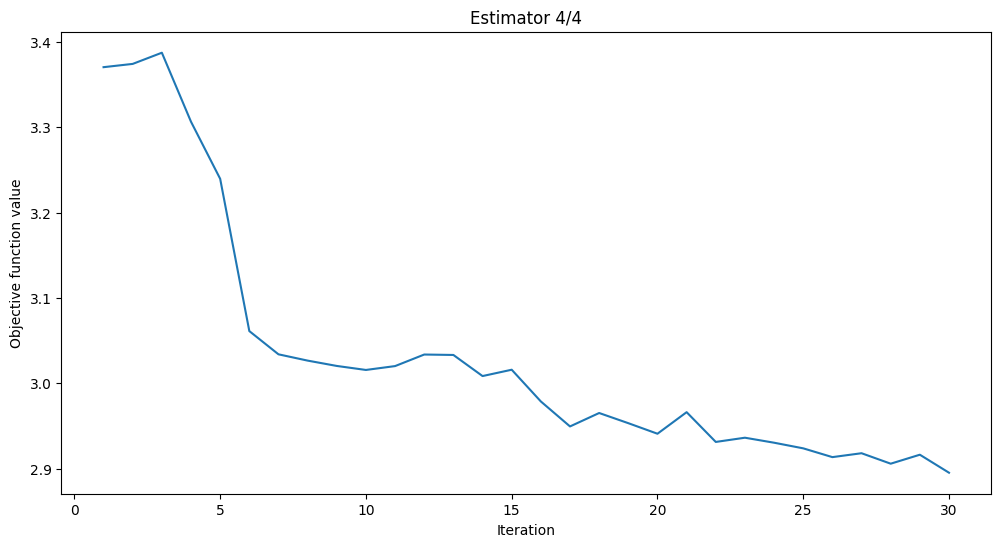

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Iteration 30: avg_change=1.467e-02, scale=4.917e-01, rtol=1.475e-02
Optimization stopped at iteration 30


In [54]:
samples = 500
estimators = [
    Estimator('top', [top_features[i] for i in range(0, n_qubits)], samples),
    # Estimator('top', [top_features[i] for i in range(n_qubits, n_qubits*2)], samples),
    # Estimator('top', [top_features[i] for i in range(0, n_qubits*2, 2)], samples),
    # Estimator('top', [top_features[i] for i in range(1, n_qubits*2, 2)], samples),
    Estimator('famd', list(range(0, n_qubits)), samples),
    # Estimator('famd', list(range(n_qubits, n_qubits*2)), samples),
    # Estimator('famd', list(range(0, n_qubits*2, 2)), samples),
    # Estimator('famd', list(range(1, n_qubits*2, 2)), samples)
]

for estimator in estimators:
    print(f"Estimator type: {estimator.type}, features: {estimator.features}, samples: {estimator.samples}")

test_ensemble = EnsembleVQC(estimators, size=2)

Xt_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[top_features[:8]]), columns=top_features[:8])
Xt_test_scaled = pd.DataFrame(scaler.transform(X_test[top_features[:8]]), columns=top_features[:8])

Xf_train_scaled = pd.DataFrame(scaler.fit_transform(Xf_train[range(8)]), columns=Xf_train.columns[:8])
Xf_test_scaled = pd.DataFrame(scaler.transform(Xf_test[range(8)]), columns=Xf_test.columns[:8])

test_ensemble.train(Xt_train_scaled, Xf_train_scaled, y_train)

In [55]:
print(f"Training time: {np.sum([estimator.training_time for estimator in test_ensemble.estimators])} seconds")

train_preds = test_ensemble.predict(Xt_train_scaled, Xf_train_scaled)
train_score = accuracy_score(y_train, train_preds)

print("\n--- Majority Voting ---")
print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, test_ensemble.predict(Xt_test_scaled, Xf_test_scaled), zero_division=0))

train_preds = test_ensemble.predict_proba(Xt_train_scaled, Xf_train_scaled)
train_score = accuracy_score(y_train, train_preds)

print(f"--- Probability Voting ---")
print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, test_ensemble.predict_proba(Xt_test_scaled, Xf_test_scaled), zero_division=0))

Training time: 757.4629204273224 seconds

--- Majority Voting ---
Training Accuracy: 0.29
Classification Report:
               precision    recall  f1-score   support

           1       0.22      0.34      0.26        58
           2       0.13      0.26      0.17        58
           I       0.10      0.02      0.03        54
           N       0.48      0.24      0.32        58
          O1       0.09      0.03      0.04        70
          O2       0.19      0.25      0.21        60
          O3       0.56      0.62      0.59        65

    accuracy                           0.25       423
   macro avg       0.25      0.25      0.23       423
weighted avg       0.25      0.25      0.24       423

--- Probability Voting ---
Training Accuracy: 0.30
Classification Report:
               precision    recall  f1-score   support

           1       0.19      0.40      0.26        58
           2       0.12      0.22      0.15        58
           I       0.44      0.13      0.20        

#### Looking at the results, we can already see that the ensemble approach provides a significant boost in performance, achieving a testing accuracy of 33%, the F1-scores for the majority of the classes have also improved, indicating that the ensemble is able to capture a more comprehensive representation of the data distribution compared to the individual models.

## Full Search

#### To further improve the performance of the ensemble, a search was conducted over different combinations of VQC configurations, including different feature subsets, feature maps, ansatze.

#### The search was conducted over 96 combinations of feature type, feature map, and ansatz, drawn from ZFeatureMap, ZZFeatureMap, and PauliFeatureMap for encoding, and RealAmplitudes and EfficientSU2 for the variational layer.

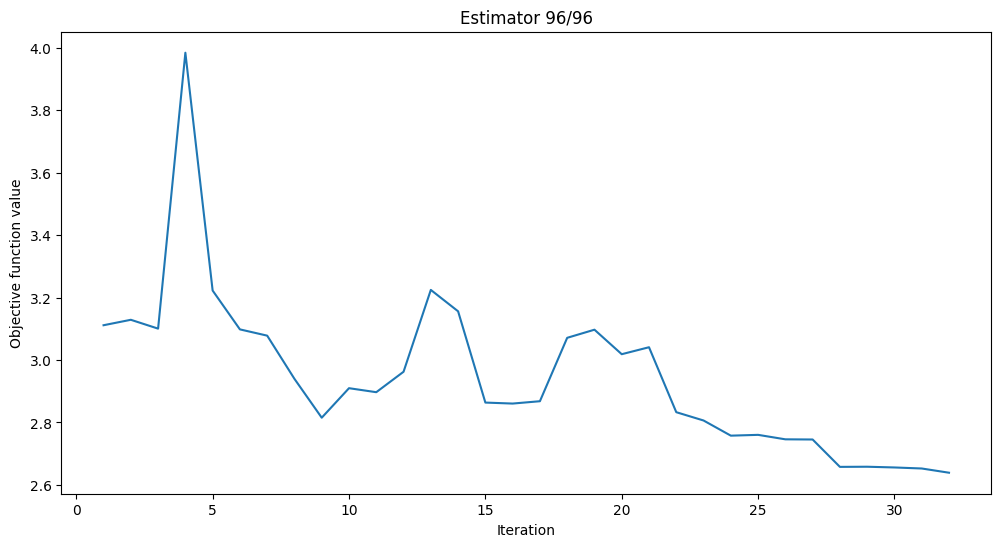

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Iteration 32: avg_change=3.820e-02, scale=1.345e+00, rtol=4.036e-02
Optimization stopped at iteration 32


In [ ]:
samples = 300
estimators = [
    Estimator('top', [top_features[i] for i in range(0, n_qubits)], samples),
    Estimator('top', [top_features[i] for i in range(n_qubits, n_qubits*2)], samples),
    Estimator('top', [top_features[i] for i in range(0, n_qubits*2, 2)], samples),
    Estimator('top', [top_features[i] for i in range(1, n_qubits*2, 2)], samples),
    Estimator('famd', list(range(0, n_qubits)), samples),
    Estimator('famd', list(range(n_qubits, n_qubits*2)), samples),
    Estimator('famd', list(range(0, n_qubits*2, 2)), samples),
    Estimator('famd', list(range(1, n_qubits*2, 2)), samples)
]

feature_maps = [
    z_feature_map(feature_dimension=n_qubits, reps=2),
    zz_feature_map(feature_dimension=n_qubits, reps=2),
    pauli_feature_map(feature_dimension=n_qubits, reps=2)
]
ansatze = [
    real_amplitudes(num_qubits=n_qubits, reps=3, entanglement='circular'),
    real_amplitudes(num_qubits=n_qubits, reps=2, entanglement='full'),
    efficient_su2(num_qubits=n_qubits, reps=2, entanglement='circular'),
    efficient_su2(num_qubits=n_qubits, reps=2, entanglement='full')
]

final_ensemble = EnsembleVQC(estimators, feature_maps=feature_maps, ansatze=ansatze)

Xt_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[top_features[:8]]), columns=top_features[:8])
Xt_test_scaled = pd.DataFrame(scaler.transform(X_test[top_features[:8]]), columns=top_features[:8])

Xf_train_scaled = pd.DataFrame(scaler.fit_transform(Xf_train[range(8)]), columns=Xf_train.columns[:8])
Xf_test_scaled = pd.DataFrame(scaler.transform(Xf_test[range(8)]), columns=Xf_test.columns[:8])

final_ensemble.train(Xt_train_scaled, Xf_train_scaled, y_train)

#### The ensemble is then constructed using the top 15% of the models based on their individual accuracies. The final ensemble achieves a testing accuracy of 40%, when using the majority voting mechanism. In testing, however, this accuracy fluctuated between ~36-40%. 

#### However, the probability-based voting mechanism, achieved a testing accuracy of 44%, which fluctuated by only ±1% across different runs, demonstrating that the dynamic weighting of model predictions based on their historical performance can lead to more stable and improved ensemble performance compared to majority voting.

In [57]:
print(f"Training time: {np.sum([estimator.training_time for estimator in final_ensemble.estimators])} seconds")

train_preds = final_ensemble.predict(Xt_train_scaled, Xf_train_scaled, threshold=0.15)
train_score = accuracy_score(y_train, train_preds)

print("\n--- Majority Voting ---")
print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, final_ensemble.predict(Xt_test_scaled, Xf_test_scaled, threshold=0.15), zero_division=0))

train_preds = final_ensemble.predict_proba(Xt_train_scaled, Xf_train_scaled, threshold=0.15)
train_score = accuracy_score(y_train, train_preds)

print(f"--- Probability Voting ---")
print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, final_ensemble.predict_proba(Xt_test_scaled, Xf_test_scaled, threshold=0.15), zero_division=0))

Training time: 11438.62576508522 seconds

--- Majority Voting ---
Training Accuracy: 0.41
Classification Report:
               precision    recall  f1-score   support

           1       0.18      0.21      0.19        58
           2       0.25      0.36      0.30        58
           I       0.57      0.43      0.49        54
           N       0.75      0.05      0.10        58
          O1       0.33      0.24      0.28        70
          O2       0.32      0.48      0.39        60
          O3       0.76      1.00      0.86        65

    accuracy                           0.40       423
   macro avg       0.45      0.40      0.37       423
weighted avg       0.45      0.40      0.38       423

--- Probability Voting ---
Training Accuracy: 0.43
Classification Report:
               precision    recall  f1-score   support

           1       0.19      0.29      0.23        58
           2       0.22      0.24      0.23        58
           I       0.79      0.48      0.60        

In [58]:
for i, est in enumerate(final_ensemble.estimators[:5]):
    print(f"Estimator {i+1}: {est.type}, features: {est.features}, feature map: {est.vqc.kwarg['feature_map'].name}, ansatz: {est.vqc.kwarg['ansatz'].name}")

    df = pd.DataFrame(est.report).transpose()
    display(df)

Estimator 1: famd, features: [1, 3, 5, 7], feature map: ZZFeatureMap, ansatz: EfficientSU2


,precision,recall,f1-score,support
1,0.287879,0.163793,0.208791,232.000000
2,0.227373,0.443966,0.300730,232.000000
I,0.095541,0.068807,0.080000,218.000000
N,0.221374,0.126638,0.161111,229.000000
O1,0.090909,0.003559,0.006849,281.000000
O2,0.364611,0.573840,0.445902,237.000000
O3,0.591647,0.984556,0.739130,259.000000
accuracy,0.341825,0.341825,0.341825,0.341825
macro avg,0.268476,0.337880,0.277502,1688.000000
weighted avg,0.270294,0.341825,0.279373,1688.000000


Estimator 2: famd, features: [0, 1, 2, 3], feature map: ZZFeatureMap, ansatz: RealAmplitudes


,precision,recall,f1-score,support
1,0.085714,0.064655,0.073710,232.000000
2,0.189358,0.521552,0.277842,232.000000
I,0.416667,0.206422,0.276074,218.000000
N,0.296875,0.082969,0.129693,229.000000
O1,0.371429,0.323843,0.346008,281.000000
O2,0.297872,0.118143,0.169184,237.000000
O3,0.707989,0.992278,0.826367,259.000000
accuracy,0.341232,0.341232,0.341232,0.341232
macro avg,0.337986,0.329980,0.299840,1688.000000
weighted avg,0.344177,0.341232,0.309714,1688.000000


Estimator 3: famd, features: [1, 3, 5, 7], feature map: ZZFeatureMap, ansatz: EfficientSU2


,precision,recall,f1-score,support
1,0.145455,0.103448,0.120907,232.0000
2,0.233202,0.254310,0.243299,232.0000
I,0.317073,0.059633,0.100386,218.0000
N,0.272727,0.013100,0.025000,229.0000
O1,0.207900,0.355872,0.262467,281.0000
O2,0.353312,0.472574,0.404332,237.0000
O3,0.609524,0.988417,0.754050,259.0000
accuracy,0.335900,0.335900,0.335900,0.3359
macro avg,0.305599,0.321051,0.272920,1688.0000
weighted avg,0.307729,0.335900,0.282573,1688.0000


Estimator 4: top, features: ['X2', 'X6', 'X10', 'X17'], feature map: ZFeatureMap, ansatz: RealAmplitudes


,precision,recall,f1-score,support
1,0.129121,0.202586,0.157718,232.000000
2,0.363636,0.120690,0.181230,232.000000
I,0.761364,0.307339,0.437908,218.000000
N,0.536585,0.384279,0.447837,229.000000
O1,0.095238,0.007117,0.013245,281.000000
O2,0.192982,0.417722,0.264000,237.000000
O3,0.503254,0.895753,0.644444,259.000000
accuracy,0.333531,0.333531,0.333531,0.333531
macro avg,0.368883,0.333641,0.306626,1688.000000
weighted avg,0.359015,0.333531,0.302047,1688.000000


Estimator 5: famd, features: [1, 3, 5, 7], feature map: ZZFeatureMap, ansatz: EfficientSU2


,precision,recall,f1-score,support
1,0.204013,0.262931,0.229755,232.000000
2,0.182482,0.215517,0.197628,232.000000
I,0.222222,0.064220,0.099644,218.000000
N,0.171875,0.048035,0.075085,229.000000
O1,0.343137,0.249110,0.288660,281.000000
O2,0.298137,0.607595,0.400000,237.000000
O3,0.704319,0.818533,0.757143,259.000000
accuracy,0.332938,0.332938,0.332938,0.332938
macro avg,0.303741,0.323706,0.292559,1688.000000
weighted avg,0.312186,0.332938,0.302182,1688.000000


## Search Results

#### Across the 96 configurations evaluated, individual model testing accuracies ranged from 20% to 34% on the training set. ZZFeatureMap was the dominant feature map amongst the higher-performing configurations, appearing in four of the top five models. FAMD-derived features similarly performed better than the top features, opposite to the findings from the classical baselines.

#### Examining the per-class F1-scores across the top models reveals a more nuanced picture than the aggregate accuracy figures alone convey. Whilst individual class accuracies vary significantly across configurations, the distribution of class-level performance is largely consistent from model to model. Class O3 generally achieves the highest F1-scores across all configurations, whilst classes N, I, and O1 consistently yield the lowest. This pattern holds regardless of the specific combination of feature type, feature map, or ansatz employed, indicating that more work is needed to identify configurations that can more effectively diversify the class-level performance profiles of the constituent models in the ensemble.

## Individual vs Ensemble

#### The ensemble model demonstrates a clear advantage over individual models. Looking at the highest-ranked individual models the testing accuracy ranges from 33-34% with the macro-average F1-score ranging from 0.27-0.30, whilst the ensemble achieves 42% accuracy with a macro-average of 0.38 when combined. This difference demonstrates that the aggregation of diverse, complementary decision boundaries produces a more stable and representative classifier than a model in isolation, and that the performance floor of the EnsembleVQC is higher than that of a single VQC.

---
---

# Cloud Deployment

## Simulated Noise

#### The final stage of the experimental design involved transitioning the models from ideal statevector simulations to noisy quantum environments. The ensemble was initially executed using a noisy simulator configured on the connectivity and error rates of the ibm_kingston backend. This provided an ideal environment to observe the impact of noise on the ensemble's performance and to train the model that will then be deployed on the real quantum hardware.

In [ ]:
service = QiskitRuntimeService(channel="ibm_quantum_platform", token="GM5WfJygvyOZbef_sGQe1xU1IRA_xgXUtjRqTg2V7psc")

real_backend = service.backend("ibm_kingston")
kingston_simulator = AerSimulator.from_backend(real_backend)

pm = generate_preset_pass_manager(optimization_level=2, backend=kingston_simulator)

qiskit_runtime_service._discover_account:WARNING:2026-04-24 19:28:07,104: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-24 19:28:12,749: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-24 19:28:12,749: Using instance: open-instance, plan: open


#### Due to the significant increase in computational complexity and runtime, only the top 5 model configurations from the search were selected for training on the noisy simulator.

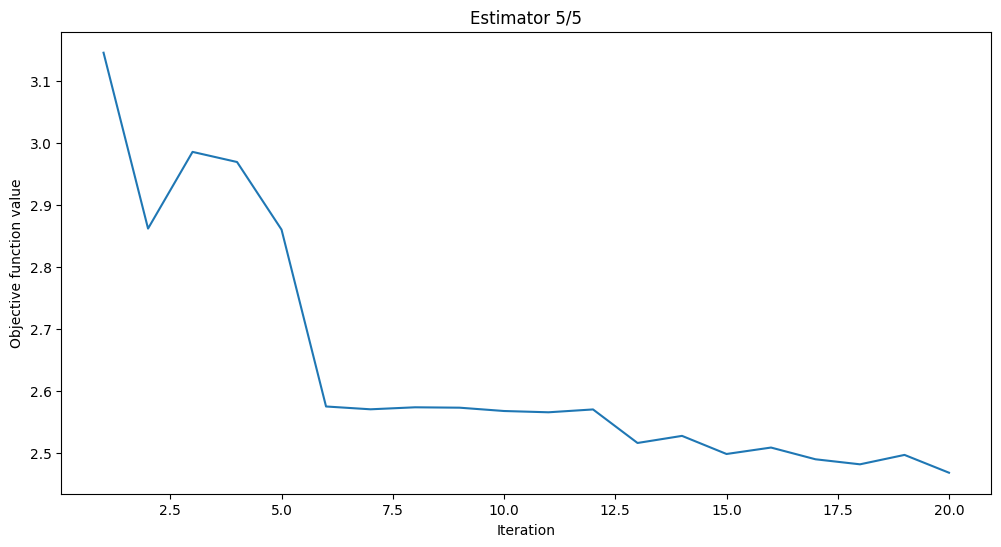

Iteration 20: avg_change=1.403e-02, scale=6.771e-01, rtol=2.031e-02
Optimization stopped at iteration 20


In [60]:
noisy_sampler = SamplerV2(kingston_simulator)

estimators = []
for est in final_ensemble.estimators[:5]:
    noisy_vqc = CustomVQC(
        sampler=noisy_sampler,
        pass_manager=pm,
        feature_map=est.vqc.kwarg["feature_map"],
        ansatz=est.vqc.kwarg["ansatz"],
        optimizer=SPSA(maxiter=100),
        output_shape=N
    )
    estimators.append(Estimator(est.type, est.features, est.samples, vqc=noisy_vqc))

noisy_ensemble = EnsembleVQC(estimators)
noisy_ensemble.train(Xt_train_scaled, Xf_train_scaled, y_train)

In [61]:
sampler = SamplerV2(kingston_simulator)
for est in noisy_ensemble.estimators:
    est.vqc.neural_network.sampler = sampler

print(f"Training time: {np.sum([estimator.training_time for estimator in noisy_ensemble.estimators])} seconds")

train_preds = noisy_ensemble.predict(Xt_train_scaled, Xf_train_scaled, threshold=1)
train_score = accuracy_score(y_train, train_preds)

print(f"\n--- Majority Voting on Simulated Backend ---")
print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, noisy_ensemble.predict(Xt_test_scaled, Xf_test_scaled, threshold=1), zero_division=0))

train_preds = noisy_ensemble.predict_proba(Xt_train_scaled, Xf_train_scaled, threshold=1)
train_score = accuracy_score(y_train, train_preds)

print(f"--- Probability Voting on Simulated Backend ---")
print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, noisy_ensemble.predict_proba(Xt_test_scaled, Xf_test_scaled, threshold=1), zero_division=0))

Training time: 6402.469437599182 seconds

--- Majority Voting on Simulated Backend ---
Training Accuracy: 0.32
Classification Report:
               precision    recall  f1-score   support

           1       0.18      0.26      0.21        58
           2       0.18      0.57      0.27        58
           I       0.50      0.15      0.23        54
           N       0.18      0.05      0.08        58
          O1       0.48      0.16      0.24        70
          O2       0.12      0.02      0.03        60
          O3       0.73      1.00      0.84        65

    accuracy                           0.32       423
   macro avg       0.34      0.31      0.27       423
weighted avg       0.35      0.32      0.28       423

--- Probability Voting on Simulated Backend ---
Training Accuracy: 0.31
Classification Report:
               precision    recall  f1-score   support

           1       0.20      0.48      0.29        58
           2       0.16      0.48      0.24        58
         

#### The final ensemble, when trained and evaluated on the noisy simulator, achieved a testing accuracy of 32%, a notable decrease from the ideal statevector performance.

#### Both voting strategies degraded under noise, however the probability-based voting mechanism suffered a substantially more severe reduction. This asymmetric sensitivity reflects the mechanism by which gate errors and decoherence corrupt the VQC's output. Under noise, gate errors flatten and redistribute probability mass across all classes simultaneously, reducing the confidence assigned to the correct class whilst artificially inflating scores for incorrect ones. Majority voting, which depends only on the argmax of each model's output and is therefore insensitive to the magnitude of the underlying probabilities, proved considerably more resilient and was the more consistent aggregation strategy when operating under hardware noise.

In [62]:
for i, est in enumerate(noisy_ensemble.estimators):
    print(f"Estimator {i+1}: {est.type}, features: {est.features}, feature map: {est.vqc.kwarg['feature_map'].name}, ansatz: {est.vqc.kwarg['ansatz'].name}")

    df = pd.DataFrame(est.report).transpose()
    display(df)

Estimator 1: famd, features: [0, 1, 2, 3], feature map: ZZFeatureMap, ansatz: RealAmplitudes


,precision,recall,f1-score,support
1,0.192369,0.521552,0.281069,232.000000
2,0.158915,0.176724,0.167347,232.000000
I,0.327434,0.169725,0.223565,218.000000
N,0.400000,0.026201,0.049180,229.000000
O1,0.442478,0.355872,0.394477,281.000000
O2,0.107143,0.012658,0.022642,237.000000
O3,0.613365,0.992278,0.758112,259.000000
accuracy,0.334716,0.334716,0.334716,0.334716
macro avg,0.320243,0.322144,0.270913,1688.000000
weighted avg,0.327648,0.334716,0.282344,1688.000000


Estimator 2: famd, features: [1, 3, 5, 7], feature map: ZZFeatureMap, ansatz: EfficientSU2


,precision,recall,f1-score,support
1,0.205128,0.172414,0.187354,232.000000
2,0.173261,0.547414,0.263212,232.000000
I,0.122807,0.032110,0.050909,218.000000
N,0.225275,0.179039,0.199513,229.000000
O1,0.484848,0.170819,0.252632,281.000000
O2,0.113402,0.046414,0.065868,237.000000
O3,0.729231,0.915058,0.811644,259.000000
accuracy,0.302725,0.302725,0.302725,0.302725
macro avg,0.293422,0.294752,0.261590,1688.000000
weighted avg,0.306952,0.302725,0.271406,1688.000000


Estimator 3: famd, features: [1, 3, 5, 7], feature map: ZZFeatureMap, ansatz: EfficientSU2


,precision,recall,f1-score,support
1,0.159722,0.099138,0.122340,232.000000
2,0.188776,0.478448,0.270732,232.000000
I,0.386139,0.178899,0.244514,218.000000
N,0.103030,0.074236,0.086294,229.000000
O1,0.127490,0.113879,0.120301,281.000000
O2,0.066667,0.012658,0.021277,237.000000
O3,0.649746,0.988417,0.784074,259.000000
accuracy,0.284953,0.284953,0.284953,0.284953
macro avg,0.240224,0.277954,0.235647,1688.000000
weighted avg,0.242022,0.284953,0.240628,1688.000000


Estimator 4: famd, features: [1, 3, 5, 7], feature map: ZZFeatureMap, ansatz: EfficientSU2


,precision,recall,f1-score,support
1,0.178947,0.219828,0.197292,232.000000
2,0.126761,0.193966,0.153322,232.000000
I,0.084175,0.114679,0.097087,218.000000
N,0.307692,0.034934,0.062745,229.000000
O1,0.231884,0.056940,0.091429,281.000000
O2,0.361111,0.219409,0.272966,237.000000
O3,0.500000,0.988417,0.664073,259.000000
accuracy,0.268365,0.268365,0.268365,0.268365
macro avg,0.255796,0.261167,0.219845,1688.000000
weighted avg,0.260651,0.268365,0.224677,1688.000000


Estimator 5: top, features: ['X2', 'X6', 'X10', 'X17'], feature map: ZFeatureMap, ansatz: RealAmplitudes


,precision,recall,f1-score,support
1,0.175655,0.491379,0.258797,232.00000
2,0.162437,0.413793,0.233293,232.00000
I,1.000000,0.027523,0.053571,218.00000
N,0.259494,0.179039,0.211886,229.00000
O1,0.214953,0.081851,0.118557,281.00000
O2,0.061538,0.016878,0.026490,237.00000
O3,0.196429,0.084942,0.118598,259.00000
accuracy,0.181280,0.181280,0.181280,0.18128
macro avg,0.295786,0.185058,0.145885,1688.00000
weighted avg,0.285381,0.181280,0.144950,1688.00000


#### A further observation of note is that the EnsembleVQC does not outperform the best individual model in the noisy setting. Beyond the noise-related degradation of the circuits, one likely contributing factor is the composition of the ensemble itself. By selecting only the top five models from the search by individual accuracy, the ensemble is constructed from configurations that exhibit very similar performance. This suggests that the weaker models in the search, those ranked lower by individual accuracy but potentially exhibiting more distinct class-level strengths, may in fact be a more valuable component of a noise-resilient ensemble than the top performers. The deliberate inclusion of lower-ranked but complementary models, rather than selecting strictly by accuracy, is therefore an important consideration for future work on this architecture.

In [ ]:
raise Exception("Save real hardware results from being overwritten if run all is pressed")

---

## Real Hardware Inference

#### The final step involved deploying the top performing model from the noisy simulator on the real quantum hardware, specifically the ibm_kingston backend. This allowed for an evaluation of the model's performance in a real-world quantum environment, accounting for all sources of noise and error inherent to current quantum devices. The best individual model and the ensemble were both tested on the same set of 100 test samples.

#### Deploying just the top performing model on the real Quantum Processing Unit we achieve a testing accuracy of 42%, which is a competitive result compared to the ideal and noisy simulator performance, although this could be attributed to the reduced test set.

In [ ]:
sampler = SamplerV2(real_backend, options={"default_shots": 1024})
for est in noisy_ensemble.estimators:
    est.vqc.neural_network.sampler = sampler

print("--- Top Model on Real Backend ---")
preds = noisy_ensemble.predict(Xt_test_scaled[:100], Xf_test_scaled[:100], threshold=0)
print("Classification Report:\n", classification_report(y_test[:100], preds, zero_division=0))

--- Top Model on Real Backend ---
Classification Report:
               precision    recall  f1-score   support

           1       0.43      0.35      0.39        17
           2       0.13      0.20      0.16        15
           I       0.22      0.18      0.20        11
           N       0.00      0.00      0.00         7
          O1       0.58      0.47      0.52        15
          O2       0.83      0.31      0.45        16
          O3       0.56      1.00      0.72        19

    accuracy                           0.42       100
   macro avg       0.39      0.36      0.35       100
weighted avg       0.44      0.42      0.40       100



#### Deploying the full ensemble on the real quantum hardware we achieve a testing accuracy of 40%, showing that noise still does play a significant role in the performance of the models.

In [ ]:
sampler = SamplerV2(real_backend, options={"default_shots": 1024})
for est in noisy_ensemble.estimators:
    est.vqc.neural_network.sampler = sampler

print("--- Ensemble on Real Backend ---")
preds = noisy_ensemble.predict(Xt_test_scaled[:100], Xf_test_scaled[:100], threshold=1)
print("Classification Report:\n", classification_report(y_test[:100], preds, zero_division=0))

--- Ensemble on Real Backend ---
Classification Report:
               precision    recall  f1-score   support

           1       0.45      0.29      0.36        17
           2       0.17      0.33      0.22        15
           I       0.33      0.09      0.14        11
           N       0.00      0.00      0.00         7
          O1       0.58      0.47      0.52        15
          O2       0.50      0.19      0.27        16
          O3       0.51      1.00      0.68        19

    accuracy                           0.40       100
   macro avg       0.36      0.34      0.31       100
weighted avg       0.40      0.40      0.36       100



---
---

# Future Work

#### The most significant limitation identified across the experimental stages is the insufficient diversity among the ensemble's constituent models, which results in correlated class-level errors that the aggregation mechanism cannot correct. Future work should therefore prioritise diversification of the VQC configurations included in the ensemble, moving beyond accuracy-ranked selection towards strategies that explicitly maximise disagreement between the models, for instance by selecting models whose per-class F1 profiles are maximally dissimilar, or by varying circuit depth, encoding strategy, and training data distribution more substantially across the search space. The deliberate inclusion of lower-ranked but complementary models, as suggested by the noisy simulator results, is a concrete first step in this direction.

#### A second direction concerns the voting mechanism itself. The probability-based voting strategy employed here, uses the measurement distribution as a proxy for model confidence. A more principled approach would involve learning aggregation weights directly from a held-out validation set, or employing a meta-learner trained on the stacked probability outputs of the individual VQCs, both of which would allow the ensemble to exploit the full range of each model's predictive distribution rather than collapsing it to a single class.

#### Finally, inference on real hardware can be accelerated substantially by exploiting the qubit capacity of the real backend, which provides 156 qubits. Since each VQC requires only four qubits, up to 39 independent circuits could in principle be executed simultaneously on a single device, obtaining all ensemble votes within a single hardware job.